In [27]:
# Preparing the code for a full SimCLR pipeline using PyTorch and timm with ConvNeXt V2 as the backbone.

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import random
import matplotlib.pyplot as plt

# Define the custom Dataset for bi-planar X-rays
class BiPlanarXrayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.root_dir = root_dir
        self.transform = transform
        for pid in sorted(os.listdir(root_dir)):
            for side in ['left', 'right']:
                la_path = os.path.join(root_dir, pid, 'DRR', side, 'la.png')
                pa_path = os.path.join(root_dir, pid, 'DRR', side, 'pa.png')
                if os.path.exists(la_path) and os.path.exists(pa_path):
                    self.samples.append((la_path, pa_path))

        print(f"Found {len(self.samples)} samples in {root_dir}")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        la_path, pa_path = self.samples[idx]
        la_img = Image.open(la_path).convert('RGB')
        pa_img = Image.open(pa_path).convert('RGB')
        if self.transform:
            la_view1 = self.transform(la_img)
            la_view2 = self.transform(la_img)
            pa_view1 = self.transform(pa_img)
            pa_view2 = self.transform(pa_img)
        else:
            la_view1 = la_view2 = la_img
            pa_view1 = pa_view2 = pa_img

        # Return 2 positive pairs: (la1, la2) and (pa1, pa2)
        return la_view1, la_view2, pa_view1, pa_view2, idx

# Data augmentations for SimCLR
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


# SimCLR model definition
class SimCLRModel(nn.Module):
    def __init__(self, backbone_name="convnextv2_tiny", projection_dim=128):
        super(SimCLRModel, self).__init__()
        self.encoder = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        feature_dim = self.encoder.num_features
        self.projector = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Linear(feature_dim, projection_dim),
            nn.BatchNorm1d(projection_dim, affine=False)  # Important for SimCLR
        )


    def forward(self, x):
        features = self.encoder(x)
        projections = self.projector(features)
        projections = F.normalize(projections, dim=1)
        return projections


In [28]:
import os
import torch
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import random
import numpy as np
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load your model
model = SimCLRModel()
model.load_state_dict(torch.load("../checkpoints/simclr_convnext_v2_tiny.pth"))
model.eval()

# Extract only encoder for inference
encoder = model.encoder.to("cpu")
encoder.eval()

# Dataset and dataloader
dataset = BiPlanarXrayDataset("../data/processed", transform=simclr_transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=0)

# Initialize containers
features_dict = {}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for la1, la2, pa1, pa2, patient_ids in tqdm(dataloader):
        la1, pa1 = la1.to(device), pa1.to(device)
        la_feat = encoder(la1).cpu()
        pa_feat = encoder(pa1).cpu()

        for i, pid in enumerate(patient_ids):
            pid_str = str(pid)  # Ensure it's hashable
            if pid_str not in features_dict:
                features_dict[pid_str] = {}
            features_dict[pid_str]['LA'] = la_feat[i].numpy()
            features_dict[pid_str]['PA'] = pa_feat[i].numpy()

# Build feature list and labels
all_features = []
all_labels = []
all_patient_ids = []

for pid, views in features_dict.items():
    if 'LA' in views:
        all_features.append(views['LA'])
        all_labels.append('LA')
        all_patient_ids.append(pid)
    if 'PA' in views:
        all_features.append(views['PA'])
        all_labels.append('PA')
        all_patient_ids.append(pid)

# t-SNE
tsne = TSNE(n_components=2, perplexity=11, random_state=42)
features_2d = tsne.fit_transform(np.array(all_features))

# Plotting
plt.figure(figsize=(10, 6))
colors = {'LA': 'blue', 'PA': 'green'}
for label in np.unique(all_labels):
    idxs = [i for i, l in enumerate(all_labels) if l == label]
    plt.scatter(features_2d[idxs, 0], features_2d[idxs, 1], label=label,
                c=colors[label], alpha=0.6, edgecolors='k')

# Draw lines between LA and PA of same patient
patient_index_map = {}
for i, pid in enumerate(all_patient_ids):
    if pid not in patient_index_map:
        patient_index_map[pid] = {}
    patient_index_map[pid][all_labels[i]] = i

# Annotate patient IDs at the midpoint between LA and PA
for pid, views in patient_index_map.items():
    if 'LA' in views and 'PA' in views:
        la_idx = views['LA']
        pa_idx = views['PA']
        x_mid = (features_2d[la_idx, 0] + features_2d[pa_idx, 0]) / 2
        y_mid = (features_2d[la_idx, 1] + features_2d[pa_idx, 1]) / 2
        plt.text(x_mid, y_mid, str(pid), fontsize=8, color='black', alpha=0.6)
        plt.plot([features_2d[la_idx, 0], features_2d[pa_idx, 0]],
                 [features_2d[la_idx, 1], features_2d[pa_idx, 1]],
                 'k--', alpha=0.3)



plt.title("t-SNE of X-ray Feature Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


RuntimeError: Error(s) in loading state_dict for SimCLRModel:
	Missing key(s) in state_dict: "projector.0.weight", "projector.0.bias", "projector.1.weight", "projector.1.bias", "projector.1.running_mean", "projector.1.running_var", "projector.3.weight", "projector.3.bias", "projector.4.running_mean", "projector.4.running_var". 
	Unexpected key(s) in state_dict: "projection_head.net.0.weight", "projection_head.net.0.bias", "projection_head.net.1.weight", "projection_head.net.1.bias", "projection_head.net.1.running_mean", "projection_head.net.1.running_var", "projection_head.net.1.num_batches_tracked", "projection_head.net.3.weight", "projection_head.net.3.bias", "projection_head.net.4.weight", "projection_head.net.4.bias", "projection_head.net.4.running_mean", "projection_head.net.4.running_var", "projection_head.net.4.num_batches_tracked". 

✅ Loaded pretrained weights from ../checkpoints/simclr_convnext_v2_tiny_encoder_only.pth
Found 6 samples in ../data/processed


100%|██████████| 1/1 [00:01<00:00,  1.50s/it]


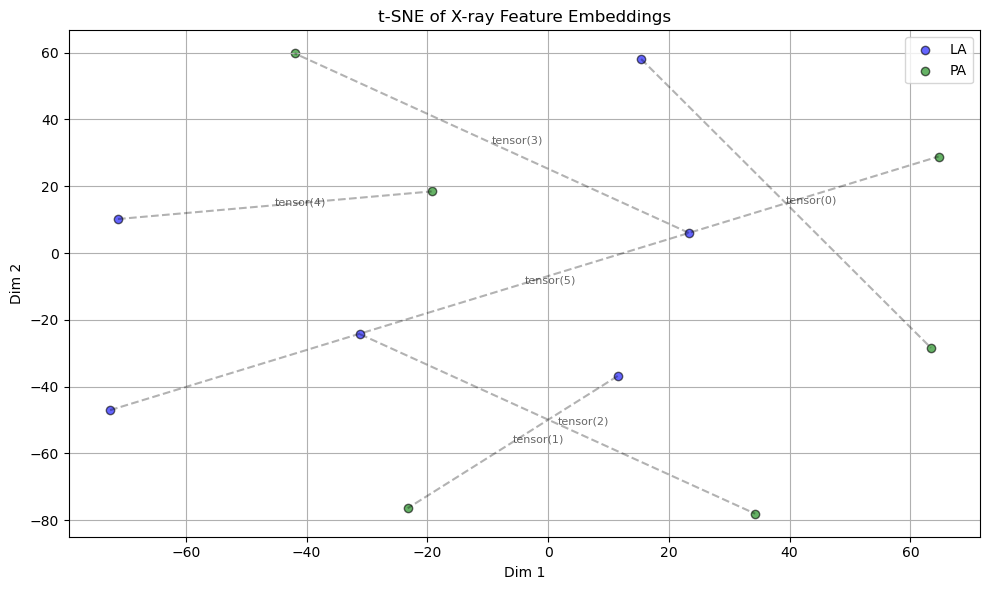

In [14]:
import os
import random
import numpy as np
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn as nn
import timm
from PIL import Image

# Define the custom Dataset for bi-planar X-rays
class BiPlanarXrayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.root_dir = root_dir
        self.transform = transform
        for pid in sorted(os.listdir(root_dir)):
            for side in ['left', 'right']:
                la_path = os.path.join(root_dir, pid, 'DRR', side, 'la.png')
                pa_path = os.path.join(root_dir, pid, 'DRR', side, 'pa.png')
                if os.path.exists(la_path) and os.path.exists(pa_path):
                    self.samples.append((la_path, pa_path))

        print(f"Found {len(self.samples)} samples in {root_dir}")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        la_path, pa_path = self.samples[idx]
        la_img = Image.open(la_path).convert('RGB')
        pa_img = Image.open(pa_path).convert('RGB')
        if self.transform:
            la_view1 = self.transform(la_img)
            la_view2 = self.transform(la_img)
            pa_view1 = self.transform(pa_img)
            pa_view2 = self.transform(pa_img)
        else:
            la_view1 = la_view2 = la_img
            pa_view1 = pa_view2 = pa_img

        # Return 2 positive pairs: (la1, la2) and (pa1, pa2)
        return la_view1, la_view2, pa_view1, pa_view2, idx

# Data augmentations for SimCLR
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=512, out_dim=128):
        super(ProjectionHead, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
            nn.BatchNorm1d(out_dim)
        )

    def forward(self, x):
        return self.net(x)

class XrayEncoder(nn.Module):
    def __init__(self, weight_path=None):
        super(XrayEncoder, self).__init__()
        self.encoder = timm.create_model('convnextv2_tiny', pretrained=False, num_classes=0)

        if weight_path is not None:
            state_dict = torch.load(weight_path, map_location='cpu')
            self.encoder.load_state_dict(state_dict)
            print(f"✅ Loaded pretrained weights from {weight_path}")

    def forward(self, x):
        return self.encoder(x)



# === Set seeds for reproducibility ===
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# === Device setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Load the model ===
model = XrayEncoder(weight_path="../checkpoints/simclr_convnext_v2_tiny_encoder_only.pth")
model.to(device)
model.eval()

# === Extract encoder only ===
encoder = model.encoder
encoder.to(device)
encoder.eval()

# === Prepare dataset and dataloader ===
dataset = BiPlanarXrayDataset("../data/processed", transform=simclr_transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=0)


# === Function to extract embeddings ===
def extract_embeddings(encoder, dataloader, device):
    features_dict = {}
    encoder.eval()
    with torch.no_grad():
        for la1, la2, pa1, pa2, patient_ids in tqdm(dataloader):
            la1, pa1 = la1.to(device), pa1.to(device)

            la_feat = encoder(la1).cpu()
            pa_feat = encoder(pa1).cpu()

            for i, pid in enumerate(patient_ids):
                pid_str = str(pid)
                if pid_str not in features_dict:
                    features_dict[pid_str] = {}
                features_dict[pid_str]['LA'] = la_feat[i].numpy()
                features_dict[pid_str]['PA'] = pa_feat[i].numpy()
    return features_dict

# === Extract features ===
features_dict = extract_embeddings(encoder, dataloader, device)

# === Prepare data for t-SNE visualization ===
all_features = []
all_labels = []
all_patient_ids = []

for pid, views in features_dict.items():
    if 'LA' in views:
        all_features.append(views['LA'])
        all_labels.append('LA')
        all_patient_ids.append(pid)
    if 'PA' in views:
        all_features.append(views['PA'])
        all_labels.append('PA')
        all_patient_ids.append(pid)

# === Run t-SNE ===
tsne = TSNE(n_components=2, perplexity=11, random_state=42, init='pca')
features_2d = tsne.fit_transform(np.array(all_features))

# === Plot the results ===
plt.figure(figsize=(10, 6))
colors = {'LA': 'blue', 'PA': 'green'}
for label in np.unique(all_labels):
    idxs = [i for i, l in enumerate(all_labels) if l == label]
    plt.scatter(features_2d[idxs, 0], features_2d[idxs, 1], label=label,
                c=colors[label], alpha=0.6, edgecolors='k')

# Draw lines between LA and PA views of the same patient
patient_index_map = {}
for i, pid in enumerate(all_patient_ids):
    if pid not in patient_index_map:
        patient_index_map[pid] = {}
    patient_index_map[pid][all_labels[i]] = i

for pid, views in patient_index_map.items():
    if 'LA' in views and 'PA' in views:
        la_idx = views['LA']
        pa_idx = views['PA']
        x_mid = (features_2d[la_idx, 0] + features_2d[pa_idx, 0]) / 2
        y_mid = (features_2d[la_idx, 1] + features_2d[pa_idx, 1]) / 2
        plt.text(x_mid, y_mid, str(pid), fontsize=8, color='black', alpha=0.6)
        plt.plot([features_2d[la_idx, 0], features_2d[pa_idx, 0]],
                 [features_2d[la_idx, 1], features_2d[pa_idx, 1]],
                 'k--', alpha=0.3)

plt.title("t-SNE of X-ray Feature Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
